In [ ]:
!pip install tensorflow pillow numpy

In [2]:
import tensorflow as tf
import numpy as np
from PIL import Image

print(tf.__version__)

2.19.0


In [1]:
interpreter = tf.lite.Interpreter(
    model_path="intel_model.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([  1, 150, 150,   3], dtype=int32), 'shape_signature': array([ -1, 150, 150,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 48, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


c:\skripsi\Dicoding\proyek-klassifikasi-gambar\venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [3]:
print(input_details[0]['shape'])

[  1 150 150   3]


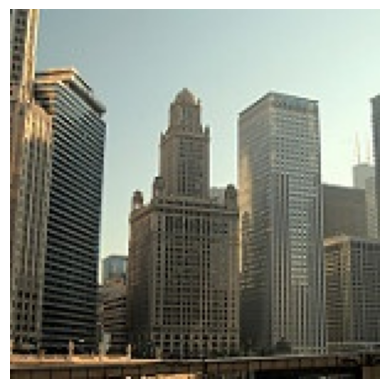

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("73.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
rescale=1./255
target_size=(150,150)
img = Image.open("73.jpg").convert("RGB")
img = img.resize((150,150))
img_array = np.array(img,dtype=np.float32)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array,axis=0)

print(img_array.shape)

(1, 150, 150, 3)


In [7]:
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

prediction = interpreter.get_tensor(output_details[0]['index'])

print(prediction)

[[9.99999762e-01 8.01555974e-11 1.11173482e-09 1.05226564e-10
  1.19432229e-07 8.11942087e-08]]


In [8]:
class_names = [
    'buildings',
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]
predicted_class = np.argmax(prediction)

print(class_names[predicted_class])

buildings


In [9]:
import time

N = 100
start = time.time()
for i in range(N):
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()

    prediction = interpreter.get_tensor(output_details[0]['index'])
end = time.time()
avg_time = ((end-start)/N)*1000

print(
    f"Average Inference Time: {avg_time:.2f} ms"
)

Average Inference Time: 10.85 ms


In [11]:
import os

size_mb = os.path.getsize(
    "intel_model.tflite"
)/(1024*1024)

print(
    f"Model Size: {size_mb:.2f} MB"
)

Model Size: 6.51 MB


In [12]:
!pip freeze > requirements.txt